In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import pandas as pd
import os, glob, json


In [17]:
# Load actual data from JSON files
json_files = glob.glob('results_*.json')

if len(json_files) == 0:
    # Use mock data if no JSON files found
    print('No JSON files found, using mock data for demonstration...')
    sizes = ['1M', '10M', '100M', '1B']
    size_multipliers = {
        '1M': 1,
        '10M': 2,
        '100M': 4,
        '1B': 8,
    }  # Larger index = longer runtime
    nqueries_list = [1, 4402]
    nprobes = [1, 2, 4, 8, 16, 32, 64, 128, 256]

    mock_results = []
    rng = np.random.default_rng(42)
    for size in sizes:
        for n_queries in nqueries_list:
            for nprobe in nprobes:
                # Base time that increases with nprobe (higher nprobe = slower but more accurate)
                # and increases with index size
                base_time = 0.1 * (nprobe / 256) * size_multipliers[size]
                query_scaling = n_queries / 1000 if n_queries > 1 else 0.01
                mean_time = base_time * query_scaling * rng.uniform(0.8, 1.2)
                std_time = mean_time * rng.uniform(0.05, 0.15)
                mock_results.append(
                    {
                        'index_path': f'speed-test-{size}-index.bin',
                        'nprobe': nprobe,
                        'n_queries': n_queries,
                        'k': 20,
                        'embedding_dim': 2560,
                        'mean_search_time': mean_time,
                        'std_search_time': std_time,
                        'size': size,
                    }
                )
    df = pd.DataFrame(mock_results)
else:
    # Load actual JSON data
    print(f'Found {len(json_files)} JSON files, loading actual data...')
    results = []
    for json_file in json_files:
        with open(json_file, 'r') as f:
            data = json.load(f)
            # Extract size from filename
            if 'results_' in json_file:
                parts = (
                    json_file.replace('results_', '')
                    .replace('.json', '')
                    .split('_')
                )
                size = parts[0]
                data['size'] = size
            results.append(data)
    df = pd.DataFrame(results)

print(f'Loaded {len(df)} data points')
df.head()


No JSON files found, using mock data for demonstration...
Loaded 72 data points


,index_path,nprobe,n_queries,k,embedding_dim,mean_search_time,std_search_time,size
0,speed-test-1M-index.bin,1,1,20,2560,0.000004,4.069387e-07,1M
1,speed-test-1M-index.bin,2,1,20,2560,0.000009,1.069623e-06,1M
2,speed-test-1M-index.bin,4,1,20,2560,0.000013,1.931384e-06,1M
3,speed-test-1M-index.bin,8,1,20,2560,0.000035,4.438754e-06,1M
4,speed-test-1M-index.bin,16,1,20,2560,0.000053,5.056323e-06,1M


In [24]:
def plot_search_time_vs_nprobe(
    df, n_queries_val, save_path=None, figsize=(10, 7)
):
    """
    Plot mean search time vs. nprobe for a specific n_queries value.

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the benchmark results
    n_queries_val : int
        The n_queries value to filter and plot
    save_path : str, optional
        Path to save the plot as PDF. If None, plot is not saved.
    figsize : tuple, optional
        Figure size (width, height) in inches
    """
    sns.set_theme(style='whitegrid')
    plt.figure(figsize=figsize)

    # Filter data for this n_queries value
    df_filtered = df[df['n_queries'] == n_queries_val]

    if df_filtered.empty:
        print(f'No data found for n_queries = {n_queries_val}')
        return

    annotation_offset = (
        df_filtered['mean_search_time'].max() * 0.02
    )  # Dynamic offset

    # Define the order of index sizes and color palette
    size_order = ['1M', '10M', '100M', '1B']
    colors = sns.color_palette('viridis', len(size_order))[
        ::-1
    ]  # viridis palette reversed (light to dark as size increases)

    for i, size in enumerate(size_order):
        if size not in df_filtered['size'].values:
            continue  # Skip if this size is not in the data

        group = df_filtered[df_filtered['size'] == size]
        # Sort by nprobe
        group = group.sort_values('nprobe')
        label = size
        color = colors[i]

        scatter = sns.scatterplot(
            x=group['nprobe'],
            y=group['mean_search_time'],
            s=100,
            edgecolor='black',
            color=color,
            label=label,
        )
        plt.plot(
            group['nprobe'],
            group['mean_search_time'],
            linestyle='-',
            marker='',
            color=color,
            alpha=0.7,
        )

    # Limit the number of y-ticks to a maximum of 7
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=7))

    # Format y-axis labels to two decimal places
    plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    # Log scale for nprobe (x-axis)
    plt.xscale('log', base=2)

    # Labels and title
    plt.xlabel('nprobe', fontsize=12)
    plt.ylabel('Mean Search Time (s)', fontsize=12)
    plt.title(
        f'IVF Search: Mean Search Time vs. nprobe (n_queries = {n_queries_val})'
    )

    # Set the legend location with reversed order and title
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(
        handles[::-1], labels[::-1], loc='upper left', title='Index Size'
    )

    # Adjust grid line appearance (lighter)
    plt.grid(True, linewidth=0.5, alpha=0.4)

    plt.tight_layout()

    # Save the plot as a high-resolution PDF if path provided
    if save_path:
        plt.savefig(save_path, format='pdf', dpi=300)
        print(f'Plot saved to: {save_path}')

    plt.show()


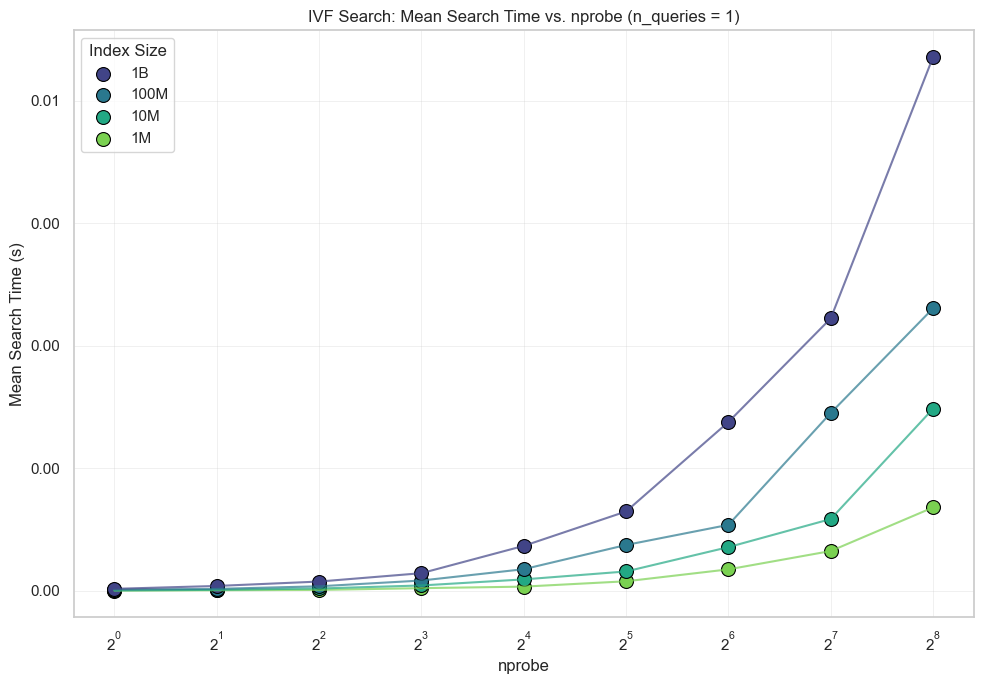

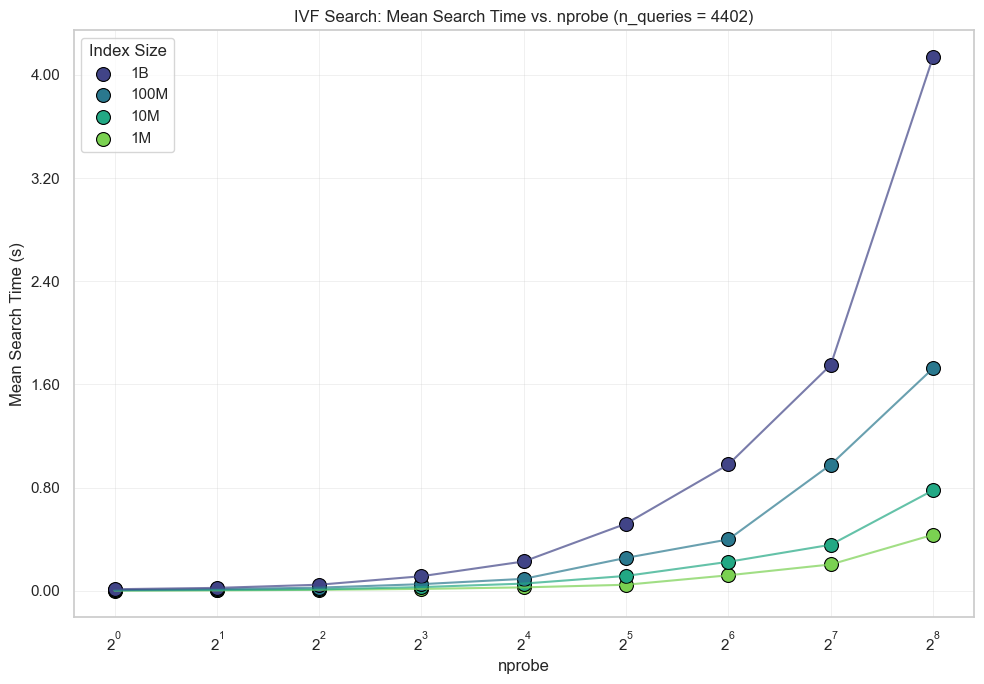

In [25]:
# Generate plots for each n_queries value
for n_queries_val in sorted(df['n_queries'].unique()):
    # Optional: save each plot to PDF
    # save_path = f'ivf_search_time_vs_nprobe_nq_{n_queries_val}.pdf'
    save_path = None  # Set to None to not save

    plot_search_time_vs_nprobe(df, n_queries_val, save_path=save_path)


# IVF Search Speed Analysis

This notebook demonstrates how to load and plot benchmarking results for FAISS IVF search, following the style guidelines from the provided plotting code. It will load actual JSON results if available, otherwise use mock data for demonstration.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import pandas as pd
import os, glob, json


## Load Data (JSON files or mock data)


In [3]:
# Load actual data from JSON files
json_files = glob.glob('results_*.json')

if len(json_files) == 0:
    # Use mock data if no JSON files found
    print('No JSON files found, using mock data for demonstration...')
    sizes = ['1M', '10M', '100M', '1B']
    nqueries_list = [1, 4402]
    nprobes = [1, 2, 4, 8, 16, 32, 64, 128, 256]

    mock_results = []
    rng = np.random.default_rng(42)
    for size in sizes:
        for n_queries in nqueries_list:
            for nprobe in nprobes:
                mean_time = (
                    rng.uniform(0.01, 0.5)
                    * (256 / nprobe)
                    * (n_queries / 1000)
                )
                std_time = mean_time * rng.uniform(0.05, 0.15)
                mock_results.append(
                    {
                        'index_path': f'speed-test-{size}-index.bin',
                        'nprobe': nprobe,
                        'n_queries': n_queries,
                        'k': 20,
                        'embedding_dim': 2560,
                        'mean_search_time': mean_time,
                        'std_search_time': std_time,
                        'size': size,
                    }
                )
    df = pd.DataFrame(mock_results)
else:
    # Load actual JSON data
    print(f'Found {len(json_files)} JSON files, loading actual data...')
    results = []
    for json_file in json_files:
        with open(json_file, 'r') as f:
            data = json.load(f)
            # Extract size from filename
            if 'results_' in json_file:
                parts = (
                    json_file.replace('results_', '')
                    .replace('.json', '')
                    .split('_')
                )
                size = parts[0]
                data['size'] = size
            results.append(data)
    df = pd.DataFrame(results)

print(f'Loaded {len(df)} data points')
df.head()


No JSON files found, using mock data for demonstration...
Loaded 72 data points


,index_path,nprobe,n_queries,k,embedding_dim,mean_search_time,std_search_time,size
0,speed-test-1M-index.bin,1,1,20,2560,0.099645,0.009355,1M
1,speed-test-1M-index.bin,2,1,20,2560,0.055131,0.006601,1M
2,speed-test-1M-index.bin,4,1,20,2560,0.003593,0.000530,1M
3,speed-test-1M-index.bin,8,1,20,2560,0.012255,0.001576,1M
4,speed-test-1M-index.bin,16,1,20,2560,0.001164,0.000111,1M


## Define Plotting Function


In [5]:
def plot_search_time_vs_nprobe(
    df,
    n_queries_val,
    save_path=None,
    figsize=(10, 7),
):
    """
    Plot mean search time vs. nprobe for a specific n_queries value.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the benchmark results
    n_queries_val : int
        The n_queries value to filter and plot
    save_path : str, optional
        Path to save the plot as PDF. If None, plot is not saved.
    figsize : tuple, optional
        Figure size (width, height) in inches
    """
    sns.set_theme(style='whitegrid')
    plt.figure(figsize=figsize)

    # Filter data for this n_queries value
    df_filtered = df[df['n_queries'] == n_queries_val]

    if df_filtered.empty:
        print(f'No data found for n_queries = {n_queries_val}')
        return

    annotation_offset = (
        df_filtered['mean_search_time'].max() * 0.02
    )  # Dynamic offset

    for size, group in df_filtered.groupby('size'):
        # Sort by nprobe
        group = group.sort_values('nprobe')
        label = f'Index Size: {size}'
        scatter = sns.scatterplot(
            x=group['nprobe'],
            y=group['mean_search_time'],
            s=100,
            edgecolor='black',
            label=label,
        )
        color = scatter.collections[-1].get_facecolor()[0]
        plt.plot(
            group['nprobe'],
            group['mean_search_time'],
            linestyle='-',
            marker='',
            color=color,
            alpha=0.7,
        )
        # Annotate points with nprobe values
        for x, y in zip(group['nprobe'], group['mean_search_time']):
            plt.text(
                x,
                y + annotation_offset,
                f'{x}',
                fontsize=9,
                ha='center',
                va='bottom',
            )

    # Limit the number of y-ticks to a maximum of 7
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=7))

    # Format y-axis labels to two decimal places
    plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    # Log scale for nprobe (x-axis)
    plt.xscale('log', base=2)

    # Labels and title
    plt.xlabel('nprobe', fontsize=12)
    plt.ylabel('Mean Search Time (s)', fontsize=12)
    plt.title(
        f'IVF Search: Mean Search Time vs. nprobe (n_queries = {n_queries_val})'
    )

    # Set the legend location
    plt.legend(loc='upper right')

    # Adjust grid line appearance (lighter)
    plt.grid(True, linewidth=0.5, alpha=0.4)

    plt.tight_layout()

    # Save the plot as a high-resolution PDF if path provided
    if save_path:
        plt.savefig(save_path, format='pdf', dpi=300)
        print(f'Plot saved to: {save_path}')

    plt.show()


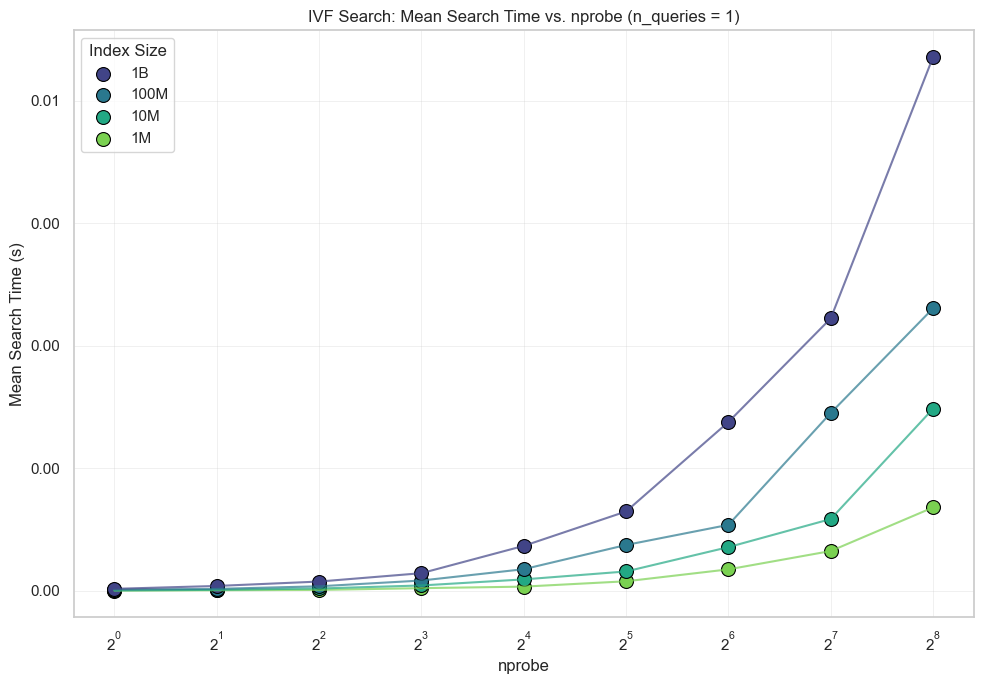

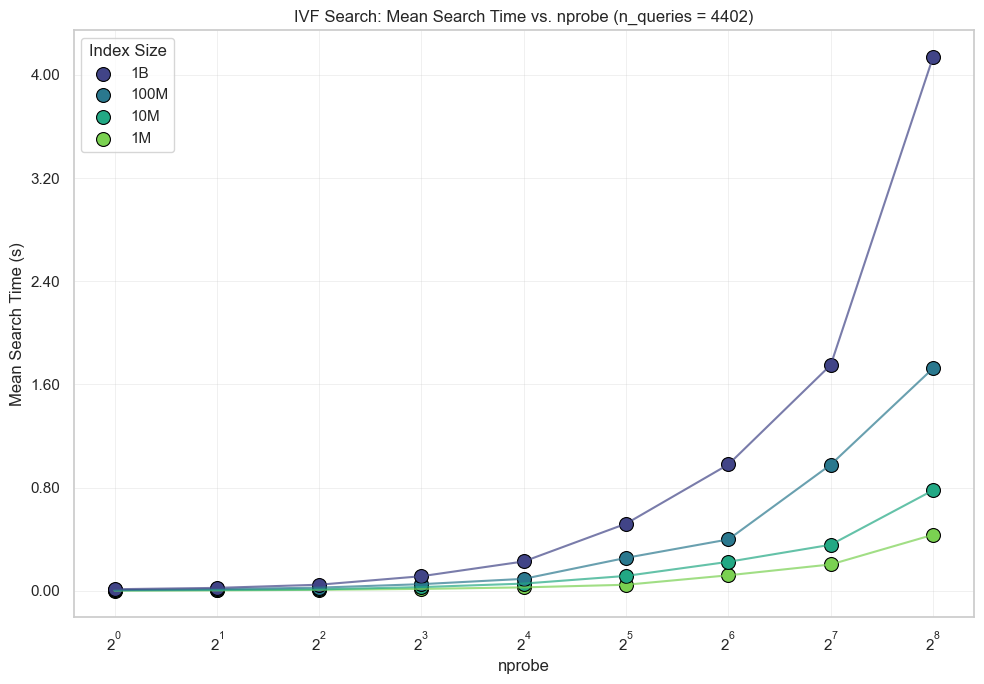

In [26]:
# Generate plots for each n_queries value
for n_queries_val in sorted(df['n_queries'].unique()):
    # Optional: save each plot to PDF
    # save_path = f'ivf_search_time_vs_nprobe_nq_{n_queries_val}.pdf'
    save_path = None  # Set to None to not save

    plot_search_time_vs_nprobe(df, n_queries_val, save_path=save_path)
